# 💻 **Actividad 1**

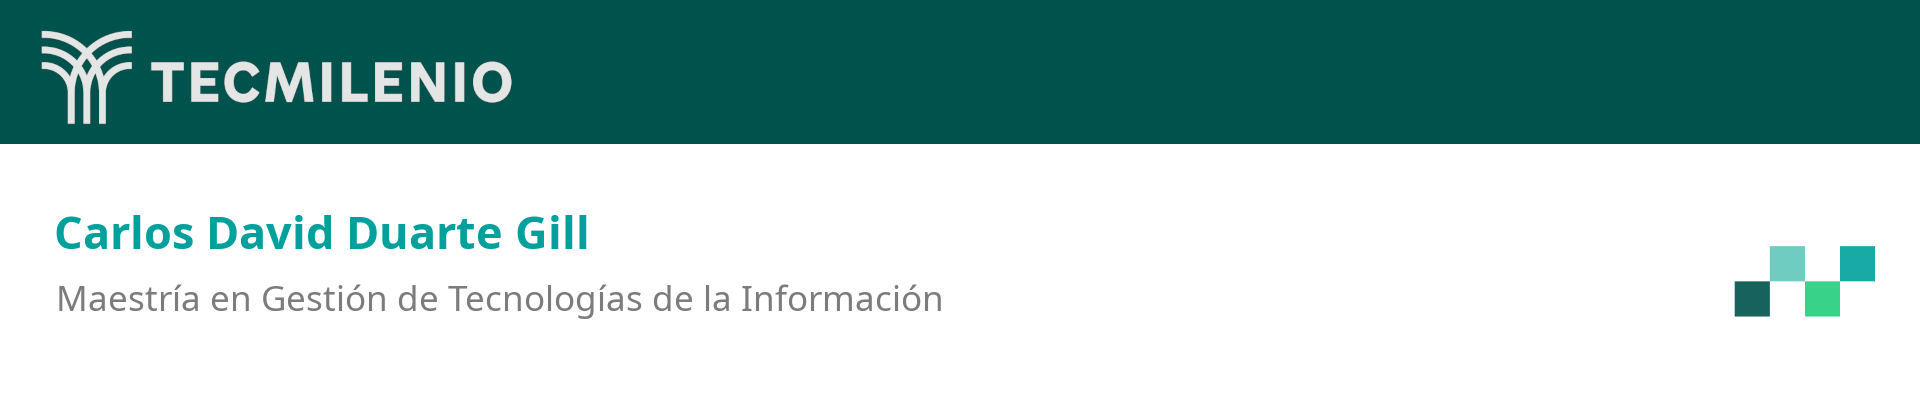

## **Gestión de calidad de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Heriberto Gonzalez Cazares
- Fecha:  lunes 16 de febrero de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción – Actividad 1

En esta actividad se realizará un análisis cualitativo de la calidad de datos sobre un conjunto de datos reales, y para ello se emplearán herramientas de Python y visualización para detectar problemas como duplicados, nulos, outliers e inconsistencias, mismos que se mapearán a dimensiones de calidad como precisión, completitud, consistencia, validez, actualidad y unicidad. 

El resultado será un diagnóstico documentado y una propuesta inicial de mejora enfocada en elevar la confiabilidad de la información antes de su uso analítico o de modelado.

## 🗽 Alcance y propósito de la Actividad 1

La actividad abarca desde la selección técnica del dataset hasta la entrega de una propuesta inicial de mejora, en el proceso se incluye:

- Identificación de variables heterogéneas.
- Ejecución de un perfilado estadístico automático.
- Documentación de hallazgos cualitativos, donde se podrá describir qué está mal y por qué.
- Justificación de las dimensiones de calidad afectadas.


### 💡 Propósito de la actividad

El objetivo principal es el desarrollar un ojo crítico, ya que no basta con saber programar; si no que se necesita entender las dimensiones de la calidad de los datos para diagnosticar si una fuente de datos es apta para su propósito o si representa un riesgo para la organización.

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Actividad 1 y asegurar todos los pasos requeridos durante su desarrollo, he decidido utilizar el conjunto de datos de **Student Performance & Academic Trends Dataset** dispuesto en [**Kaggle**](https://www.kaggle.com/datasets/ankushnarwade/ai-impact-on-student-performance)

### 📒 Acerca del conjunto de datos


Este conjunto de datos original contiene 8,000 filas y 26 columnas que capturan cómo las herramientas de aprendizaje basadas en IA influyen en el rendimiento académico de los estudiantes.

Los datos incluyen datos demográficos de los estudiantes, frecuencia de uso de herramientas de IA, tiempo dedicado a plataformas de aprendizaje basadas en IA, métricas de rendimiento, comportamiento de participación y mejoras de aprendizaje autodeclaradas.

El dataset incluye una mezcla de datos numéricos y categóricos bien definidos por lo que es ideal para la Actividad.

### 🔗 Carga el conjunto de datos en url pública

Se sube el dataset **disease_diagnosis.csv** a un repositorio público para facilitar la revisión y tratamiento del mismo. El dataset se encuentra en la url pública: https://raw.githubusercontent.com/RamRider89/gestion-calidad-datos/refs/heads/main/data/ai_impact_student_performance_dataset.csv

Notas: El dataset original contiene 8,000 registros y 26 columnas, para temas de estudio y practica se redujo el dataset a solo 1,550 para cumplir con los registros mínimos que solicita la actividad.

# 💻 Desarrollo de la Actividad 1

**A continuación:**

🧰 Se importan las librerías necesarias para el análisis y la visualización como numpy, matplotlib.pyplot y seaborn, entre otras.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [14]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tabulate import tabulate

# warnings
import warnings

# Configuracion estandar para todas las graficas
%matplotlib inline
sns.set_theme(style="whitegrid")
sns.set_style("white")
plt.rcParams['figure.figsize'] = (15, 7)

warnings.filterwarnings('ignore')

print("-" * 80)
print("¡Librerias importadas!")
print("-" * 80)

--------------------------------------------------------------------------------
¡Librerias importadas!
--------------------------------------------------------------------------------


## 🗂 Variables de entorno

In [15]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"

### 🗂 Funciones auxiliares

In [16]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

In [17]:
# ------------------------------------------------------------------------------
# 🤖 diccionario builder
# ------------------------------------------------------------------------------

def dictionary_builder(columnas_categoricas, msj):

    _dict_unique_values_ = {}

    # recorremos las columnas categoricas para obtener sus valores
    display_mensaje(msj)
    # recorreos las columnas categoricas
    for col in columnas_categoricas.columns:
        # obtenemos los vals unicos
        unique_values = columnas_categoricas[col].unique()
        # asignamos los valores unicos al dict
        _dict_unique_values_[col] = columnas_categoricas[col].unique()


    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
    # imprimiendo
    print(tabulate(data, headers=headers, tablefmt="grid"))

    return _dict_unique_values_;


# 💾 Carga de los datos

Para iniciar el análisis, cargaremos el conjunto de datos desde un repositorio publico en **GitHub**.
El dataset ha sido cargado previamente en el repositorio.

In [18]:
# ------------------------------------------------------------------------------
# CARGA DEL DATASET
# ------------------------------------------------------------------------------
# URL pública del dataset
_URL_ = "https://raw.githubusercontent.com/RamRider89/gestion-calidad-datos/refs/heads/main/data/ai_impact_student_performance_dataset.csv"

# config
pd.set_option('display.max_columns', None)

# leyendo el archivo csv mediante pandas
df = pd.read_csv(_URL_)

### 🗂 Descripción del dataframe

In [19]:
display_mensaje("Estructura inicial del DataFrame")
df.head()


 --- Estructura inicial del DataFrame --- 


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,29,56,5,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,14,65,1,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,82,8,5,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,74,106,10,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,83,7,10,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


## 🧮 Identificación de variables

A continuación se identifican cada una de las variables del dataset.

### ⏱️ Variables temporales
- ai_usage_time_minutes — minutos de uso de IA.
- ai_prompts_per_week — número de prompts por semana.
- study_hours_per_day — horas de estudio por día.
- sleep_hours — horas de sueño por día.
- social_media_hours — horas en redes sociales por día.
- tutoring_hours — horas de tutoría (p. ej., por semana).

### 🏷️ Variables categóricas (Nominales):
- student_id — identificador único del estudiante.
- gender — Genero del estudiante.
- grade_level — nivel/etapa académica.
- ai_tools_used — herramienta(s) de IA.
- ai_usage_purpose — propósito de uso.
- uses_ai — indicador de uso de IA .
- passed — condición de aprobado .
- performance_category — etiqueta de desempeño.

### 🔢 Variables cuantitativas:
- age — edad.
- ai_dependency_score — dependencia de IA.
- ai_generated_content_percentage — % de contenido generado con IA.
- ai_ethics_score — ética en uso de IA.
- last_exam_score — calificación del último examen.
- assignment_scores_avg — promedio de tareas.
- attendance_percentage — porcentaje de asistencia.
- concept_understanding_score — comprensión de conceptos.
- study_consistency_index — índice de consistencia de estudio.
- improvement_rate — tasa de mejora.
- class_participation_score — participación en clase.
- final_score — calificación final.

## 🗂 Información de la estructura

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1550 entries, 0 to 1549
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       1550 non-null   int64  
 1   age                              1550 non-null   int64  
 2   gender                           1550 non-null   object 
 3   grade_level                      1550 non-null   object 
 4   study_hours_per_day              1550 non-null   float64
 5   uses_ai                          1550 non-null   int64  
 6   ai_usage_time_minutes            1550 non-null   int64  
 7   ai_tools_used                    1305 non-null   object 
 8   ai_usage_purpose                 1293 non-null   object 
 9   ai_dependency_score              1550 non-null   int64  
 10  ai_generated_content_percentage  1550 non-null   int64  
 11  ai_prompts_per_week              1550 non-null   int64  
 12  ai_ethics_score     

In [21]:
display_mensaje("Estructura del Dataset")
print(f"Dataset shape: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")


 --- Estructura del Dataset --- 
Dataset shape: (1550, 26)
Número de filas: 1550
Número de columnas: 26


Esta vista rápida nos confirma que el dataset tiene una estructura solida.

### 🗂 Resumen de la estructura del Dataset

| Variable                        | Tipo de Dato    | Clasificación                | Descripción (breve)                               | Función en el Análisis (breve)                                   |
| ------------------------------- | --------------- | ---------------------------- | ------------------------------------------------- | ---------------------------------------------------------------- |
| student_id                      | int64           | Cualitativa (identificador)  | ID único por estudiante.                          | Verificar unicidad, detectar duplicados; no usar como predictor. |
| age                             | int64           | Cuantitativa (discreta)      | Edad en años.                                     | Segmentación demográfica; control de sesgos.                     |
| gender                          | object          | Cualitativa (nominal)        | Género reportado (Female/Male/Other).             | Análisis por grupos; ver distribución y potenciales brechas.     |
| grade_level                     | object          | Cualitativa (ordinal)        | Etapa académica (10th, 11th, 12th, 1st–3rd Year). | Comparar métricas entre niveles; control de confusores.          |
| study_hours_per_day             | float64         | Temporal (horas/día)         | Horas de estudio por día.                         | Relacionar hábitos con desempeño; checks de plausibilidad.       |
| uses_ai                         | int64           | Cualitativa (binaria)        | Indicador de uso de IA (0/1).                     | Reglas de consistencia con tiempo, herramienta y propósito.      |
| ai_usage_time_minutes           | int64           | Temporal (minutos)           | Minutos de uso de IA.                             | Valorar intensidad de uso; validar con uses_ai.                  |
| ai_tools_used                   | object          | Cualitativa (nominal)        | Herramienta(s) de IA (ChatGPT, Gemini, etc.).     | Análisis de adopción por herramienta; nulos ↔ completitud.       |
| ai_usage_purpose                | object          | Cualitativa (nominal)        | Propósito (Exam Prep, Coding, etc.).              | Ver casos de uso; coherencia con uses_ai y tiempo.               |
| ai_dependency_score             | int64           | Cuantitativa (ordinal 1–10)  | Nivel de dependencia de IA.                       | Medir relación entre dependencia y resultados.                   |
| ai_generated_content_percentage | int64           | Cuantitativa (porcentaje)    | % de contenido generado con IA (0–100).           | Evaluar impacto del % IA en el desempeño; validar rango.         |
| ai_prompts_per_week             | int64           | Temporal (frecuencia/semana) | Prompts semanales a herramientas de IA.           | Medir intensidad de interacción; detectar outliers.              |
| ai_ethics_score                 | int64           | Cuantitativa (ordinal 1–10)  | Puntuación de ética en uso de IA.                 | Explorar correlación con calidad y resultados.                   |
| last_exam_score                 | int64           | Cuantitativa (0–100)         | Calificación último examen.                       | Indicador parcial de rendimiento; validar rango.                 |
| assignment_scores_avg           | float64         | Cuantitativa (0–100)         | Promedio de tareas.                               | Métrica continua de desempeño; control de sesgo.                 |
| attendance_percentage           | float64         | Cuantitativa (porcentaje)    | Asistencia a clases (0–100).                      | Predictor del desempeño; validar límites y nulos.                |
| concept_understanding_score     | int64           | Cuantitativa (ordinal 1–10)  | Comprensión de conceptos.                         | Indicador formativo; relacionarlo con final_score.               |
| study_consistency_index         | float64         | Cuantitativa (índice)        | Consistencia del hábito de estudio.               | Detectar patrones; posible negativo/positivo.                    |
| improvement_rate                | float64         | Cuantitativa (tasa)          | Variación del rendimiento.                        | Señal temprana de mejora/deterioro; outliers.                    |
| sleep_hours                     | float64         | Temporal (horas/día)         | Horas de sueño diarias.                           | Ver hábitos saludables vs. desempeño.                            |
| social_media_hours              | float64         | Temporal (horas/día)         | Horas en redes sociales/día.                      | Evaluar distracciones; correlación con notas.                    |
| tutoring_hours                  | float64         | Temporal (horas/semana)      | Horas de tutoría.                                 | Controlar apoyo extraacadémico en modelos.                       |
| class_participation_score       | int64           | Cuantitativa (ordinal 1–10)  | Participación en clase.                           | Proxy de engagement; contraste con exámenes.                     |
| final_score                     | float64         | Cuantitativa (0–100)         | Calificación final del curso.                     | KPI principal de desempeño; base para passed.                    |
| passed                          | int64           | Cualitativa (binaria)        | Aprobado (0/1).                                   | Validación de consistencia con umbral de final_score.            |
| performance_category            | object          | Cualitativa (ordinal)        | Categoría de desempeño (Low/Medium/High).         | Segmentar resultados; análisis de dist                           |

## 🔍 Exploración inicial

Se realiza una exploración inicial con pandas, numpy, matplotlib, y una descripción del contenido general como registros, columnas, tipos y observaciones.

### 🧮 Conteo de nulos

In [22]:
# ------------------------------------------------------------------------------
# Conteos de nulos
# ------------------------------------------------------------------------------
null_count = df.isna().sum().sort_values(ascending=False)

print("\nTop 10 columnas con más nulos (conteo):\n", null_count.head(10))


Top 10 columnas con más nulos (conteo):
 ai_usage_purpose         257
ai_tools_used            245
age                        0
student_id                 0
gender                     0
grade_level                0
uses_ai                    0
study_hours_per_day        0
ai_usage_time_minutes      0
ai_dependency_score        0
dtype: int64


Los nulos encontrados podrían deberse a temas de llenado de registros durante las entrevistas o bien a la posibilidad de negar una respuesta por parte del usuario, se analizará más a fondo en los siguientes puntos si estos nulos afectan a los cálculos requeridos.

### 🔢 Estadísticos descriptivos para variables numéricas

In [23]:
# ------------------------------------------------------------------------------
# Estadísticos descriptivos para numéricas
# ------------------------------------------------------------------------------
desc_num = df.select_dtypes(include=[np.number]).describe().T
display(desc_num)
## Distribución simple de algunas variables relevantes

,count,mean,std,min,25%,50%,75%,max
student_id,1550.0,775.500000,447.590773,1.0,388.250,775.50,1162.750,1550.0
age,1550.0,18.883871,3.168304,14.0,16.000,19.00,22.000,24.0
study_hours_per_day,1550.0,3.300065,1.579760,0.5,2.000,3.30,4.675,6.0
uses_ai,1550.0,0.617419,0.486174,0.0,0.000,1.00,1.000,1.0
ai_usage_time_minutes,1550.0,86.900645,52.214428,0.0,40.000,87.00,131.000,179.0
ai_dependency_score,1550.0,5.340000,2.873469,1.0,3.000,5.00,8.000,10.0
ai_generated_content_percentage,1550.0,49.920000,29.277992,0.0,25.000,49.00,76.000,100.0
ai_prompts_per_week,1550.0,58.957419,34.786995,0.0,28.000,59.00,89.000,119.0
ai_ethics_score,1550.0,5.430968,2.864727,1.0,3.000,5.00,8.000,10.0
last_exam_score,1550.0,59.405161,22.912069,20.0,40.000,58.50,80.000,99.0


### 🔢 Distribución simple de algunas variables relevantes

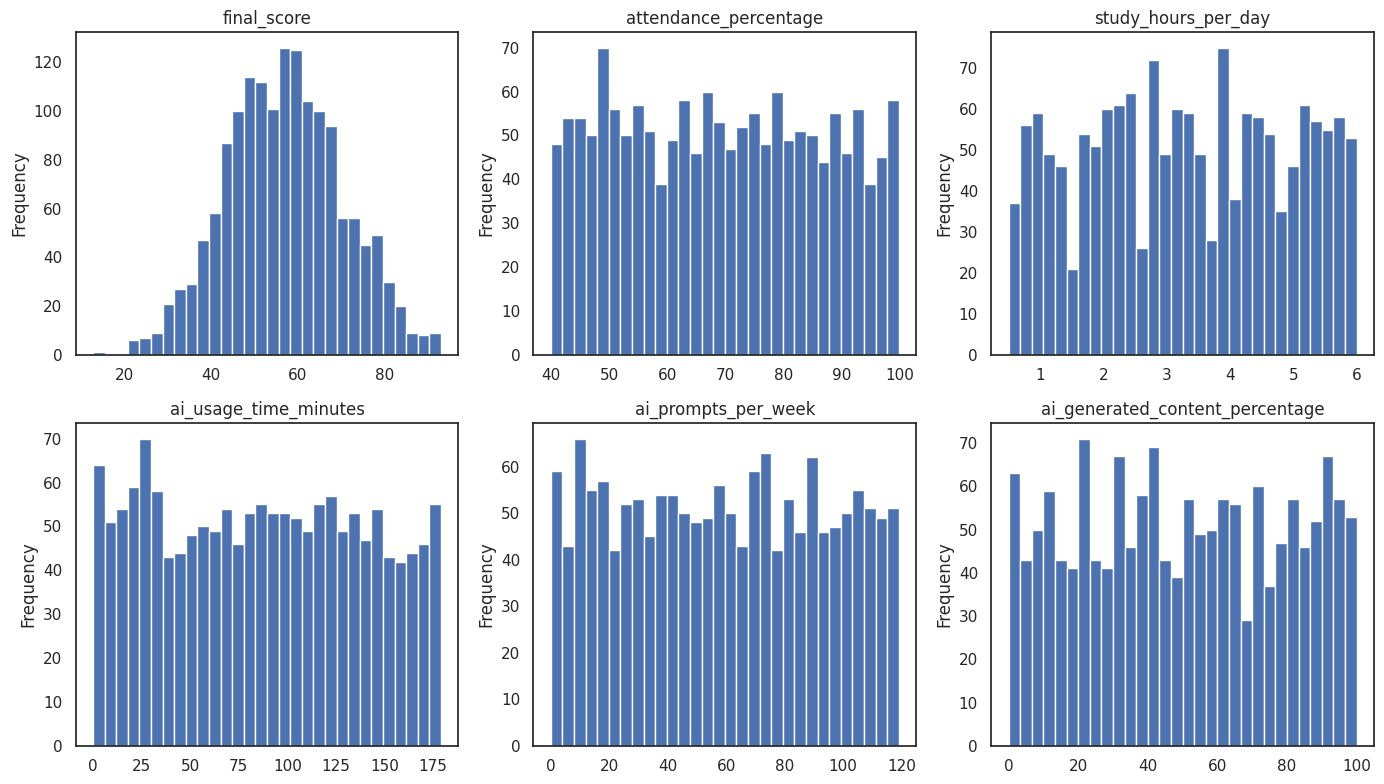

In [24]:
# ------------------------------------------------------------------------------
# Distribución simple de variables principales
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
df['final_score'].plot(kind='hist', bins=30, ax=axes[0,0], title='final_score')
df['attendance_percentage'].plot(kind='hist', bins=30, ax=axes[0,1], title='attendance_percentage')
df['study_hours_per_day'].plot(kind='hist', bins=30, ax=axes[0,2], title='study_hours_per_day')
df['ai_usage_time_minutes'].plot(kind='hist', bins=30, ax=axes[1,0], title='ai_usage_time_minutes')
df['ai_prompts_per_week'].plot(kind='hist', bins=30, ax=axes[1,1], title='ai_prompts_per_week')
df['ai_generated_content_percentage'].plot(kind='hist', bins=30, ax=axes[1,2], title='ai_generated_content_percentage')
plt.tight_layout()
plt.show()

### 🔖 Conteos de algunas categóricas

In [25]:
# ------------------------------------------------------------------------------
# Conteos de algunas categóricas
# ------------------------------------------------------------------------------
_COLUMNAS_CATEGORICAS_= ['gender','grade_level','uses_ai','performance_category','ai_tools_used','ai_usage_purpose']
for col in _COLUMNAS_CATEGORICAS_:
    if col in df.columns:
        print(f"\n{col} (conteos):\n", df[col].value_counts(dropna=False).head(10))


gender (conteos):
 gender
Female    750
Male      749
Other      51
Name: count, dtype: int64

grade_level (conteos):
 grade_level
12th        272
10th        267
2nd Year    264
3rd Year    257
11th        252
1st Year    238
Name: count, dtype: int64

uses_ai (conteos):
 uses_ai
1    957
0    593
Name: count, dtype: int64

performance_category (conteos):
 performance_category
Medium    899
Low       498
High      153
Name: count, dtype: int64

ai_tools_used (conteos):
 ai_tools_used
ChatGPT+Gemini    289
Gemini            276
ChatGPT           252
Claude            250
NaN               245
Copilot           238
Name: count, dtype: int64

ai_usage_purpose (conteos):
 ai_usage_purpose
Exam Prep        282
Doubt Solving    272
NaN              257
Coding           250
Notes            245
Homework         244
Name: count, dtype: int64


Podemos apreciar como los generes masculino y femenino están muy similares, lo mismo ocurre con los grados de estudio, teniendo un rango de estudiantes entre los 230 y 280. Sin embargo, en la variable categórica de los estudiantes que si utilizan agentes IA contra los que no, podemos ver una clara tendencia al uso de la inteligencia artificial.

## ✅ Verificación de valores únicos en columnas categóricas

In [26]:
# ------------------------------------------------------------------------------
# valores unicos en cols categóricas
# ------------------------------------------------------------------------------
# en base a nuestras columnas categoricas: _Sex_, _Smoker_, _Region_
columnas_categoricas = df[_COLUMNAS_CATEGORICAS_]
# definimos el diccionario de valores unicos

_DICT_CAT_ = dictionary_builder(columnas_categoricas, "Variables categóricas y valores únicos")



 --- Variables categóricas y valores únicos --- 
+----------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| Columna              | Valor único 1   | Valor único 2   | Valor único 3   | Valor único 4   | Valor único 5   | Valor único 6   |
+======================+=================+=================+=================+=================+=================+=================+
| gender               | Female          | Male            | Other           |                 |                 |                 |
+----------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| grade_level          | 1st Year        | 12th            | 3rd Year        | 10th            | 11th            | 2nd Year        |
+----------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| uses_ai          

Se ha revisado y verificado la estructura del Dataset encontrando variables muy interesantes en cuanto al uso de agentes IA por parte de los estudiantes.

# 🩺 Diagnóstico de calidad de datos

A continuación se realiza un diagnostico de la calidad de datos en el dataset seleccionado.

## 🈵 Completitud

Se revisa el grado en que todos los datos requeridos están presentes en el conjunto de datos. PAra ello se verifica que los registros no tienen valores faltantes.

In [27]:
# Tasas de nulos por columna
null_rate = (df.isna().mean()*100).sort_values(ascending=False)
display(null_rate.to_frame('missing_pct').head(10))

,missing_pct
ai_usage_purpose,16.580645
ai_tools_used,15.806452
age,0.000000
student_id,0.000000
gender,0.000000
grade_level,0.000000
uses_ai,0.000000
study_hours_per_day,0.000000
ai_usage_time_minutes,0.000000
ai_dependency_score,0.000000


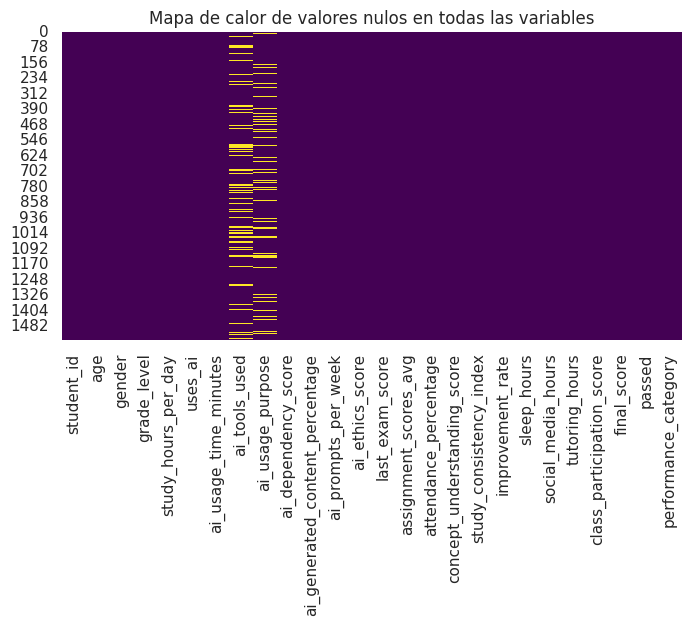

In [28]:
# ------------------------------------------------------------------------------
# mapa de calor de valores nulos
# ------------------------------------------------------------------------------
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de calor de valores nulos en todas las variables")
plt.show()

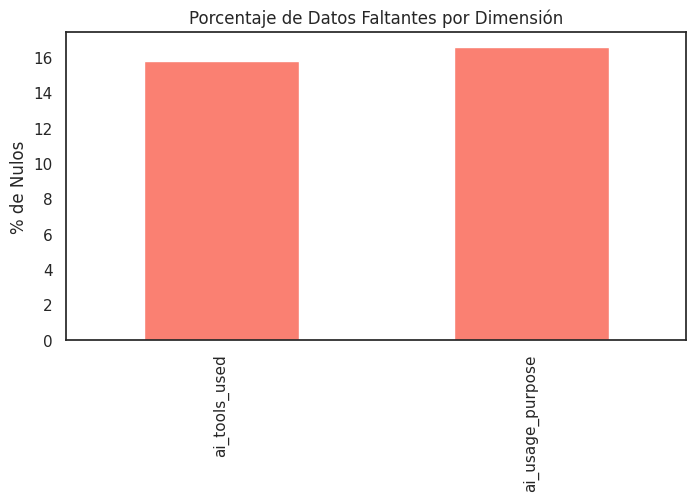

In [29]:
# ------------------------------------------------------------------------------
# valores nulos por columna
# ------------------------------------------------------------------------------
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

# graifca de barras
plt.figure(figsize=(8,4))
null_percentages[null_percentages > 0].plot(kind='bar', color='salmon')
plt.title("Porcentaje de Datos Faltantes por Dimensión")
plt.ylabel("% de Nulos")
plt.show()

La **Completitud** es el grado en que los valores requeridos están presentes y definidos para cumplir el propósito analítico.
En la tabla de completitud se muestra que solo **ai_tools_used** y **ai_usage_purpose** presentan nulos, mientras que el resto de columnas no tienen faltantes.

Dados los resultados obtenidos se recomienda priorizar la imputación y revisar las reglas de captura para las variables ai_tools_used y ai_usage_purpose. 

## ☦️ Consistencia

Se revisa que la información sea uniforme y no contradictoria a lo largo del dataset, Para ello se crean y validan algunas reglas de negocio, con la intención de buscar errores lógicos, es decir, contradicciones entre columnas que "no deberían ocurrir".

Por ejemplo, no deberían existir registros que indiquen algún tiempo de uso de agentes IA mayores a cero cuando la variable categórica **uses_ai** es negativa.

### Regla de uso de IA (uses_ai vs. Otros)

Estas reglas verifican que la historia que cuentan los datos sea coherente. Si alguien dice que "No utiliza IA", no puede haber detalles de un tiempo utlizado.

Reglas: 
- Si el estudiante marcó que no usa IA (uses_ai == 0), no tiene sentido que registre minutos de uso.
- Si el estudiante afirma usar IA, el sistema debe recabar información de cuales herramientas. Los campos adicionales no pueden estar vacios.

Sin embargo, dado el error humano, podría ocurrir un error de "Residuos de Información", cuando un estudiante cambia su respuesta a "No", pero los datos de su respuesta anterior para las herramientas se quedaron guardados en la base de datos.

##### Validación ténica

In [30]:
# ------------------------------------------------------------------------------
# verificacion de consistencia para uso de IA
# ------------------------------------------------------------------------------
N = len(df)

# reglas de negocio
violations = {
    'uses_ai_zero_but_time_positive': int(((df['uses_ai']==0) & (df['ai_usage_time_minutes']>0)).sum()),
    'uses_ai_1_but_tools_missing': int(((df['uses_ai']==1) & (df['ai_tools_used'].isna())).sum()),
    'uses_ai_0_but_tools_present': int(((df['uses_ai']==0) & (df['ai_tools_used'].notna())).sum()),
    'uses_ai_1_but_purpose_missing': int(((df['uses_ai']==1) & (df['ai_usage_purpose'].isna())).sum()),
    'uses_ai_0_but_purpose_present': int(((df['uses_ai']==0) & (df['ai_usage_purpose'].notna())).sum()),
    'passed_vs_final_score_incoherence': int((((df['final_score']>=60) & (df['passed']==0)) | ((df['final_score']<60) & (df['passed']==1))).sum()),
}

# tabla de resultados
viol_df = pd.DataFrame([
    {'regla': k, 'violaciones': v, 'violaciones_%': round(100*v/N,2)}
    for k,v in violations.items()
]).sort_values('violaciones_%', ascending=False)

display_mensaje("Violaciones a regla de negocio uses_ai")
display(viol_df)


 --- Violaciones a regla de negocio uses_ai --- 


,regla,violaciones,violaciones_%
5,passed_vs_final_score_incoherence,772,49.81
0,uses_ai_zero_but_time_positive,589,38.00
2,uses_ai_0_but_tools_present,502,32.39
4,uses_ai_0_but_purpose_present,489,31.55
1,uses_ai_1_but_tools_missing,154,9.94
3,uses_ai_1_but_purpose_missing,153,9.87


Se encuentra que el dataset tiene ciertos registros corruptos, donde se violan las principales reglas de negocio.

Las reglas de uso de IA y la etiqueta **passed** vs **final_score** concentran la mayor parte de las inconsistencias; deben definirse reglas de corrección como por ejemplo, recalcular **passed**.

### Regla de Rendimiento (passed vs. final_score)

Con esta regla podremos verificar que el "Estatus de Aprobación" coincida con la "Calificación Final".

Ejemplo, si la nota es $\geq 60$, debe decir "Aprobado" ($1$). Si es $< 60$, debe decir "Reprobado" ($0$).

Si hay inconsistencias aquí, cualquier análisis de éxito estudiantil será erróneo porque los dos indicadores principales se contradicen.

In [31]:
# ------------------------------------------------------------------------------
# Matriz Passed vs corte de final_score
# ------------------------------------------------------------------------------
df['_pass_by_score'] = (df['final_score']>=60).astype(int)
cm = pd.crosstab(df['_pass_by_score'], df['passed'], rownames=['final_score>=60'], colnames=['passed'])
display(cm)

passed,0,1
final_score>=60,,
0,157,772
1,0,621


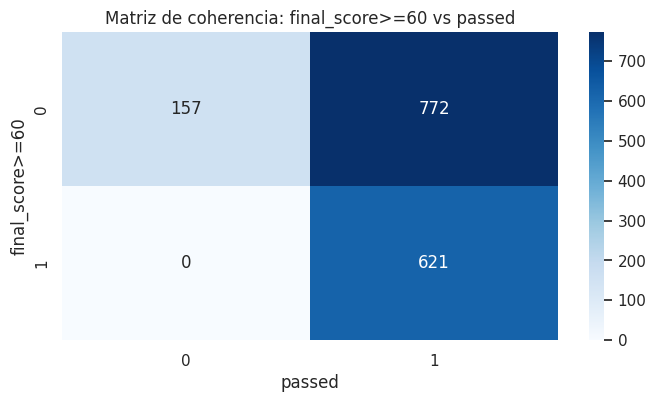

In [32]:
# ------------------------------------------------------------------------------
# grafica de matriz de coherencia
# ------------------------------------------------------------------------------
plt.figure(figsize=(8,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de coherencia: final_score>=60 vs passed')
plt.show()

# reset
df.drop(columns=['_pass_by_score'], inplace=True)

Se observan 772 registros de estudiantes marcados con la etiqueta **pased** sin embargo su calificación final es menor a 60, por lo que se esta violando una de las principales reglas del negocio.

De igual manera se observan 157 registros de estudiantes que no "pasaron" pero tienen calificación final mayor a 60, lo cuál no tiene lógica del negocio.

## 🏹 Precisión

Se revisa el grado en que los datos reflejan correctamente la realidad que pretenden representar, con ello se busca verificar que los valores deben ser veraces y estar dentro de rangos lógicos.

### Precisión de uses_ai & final_score

A continuación se valida si un estudiante declara que no utiliza IA, pero luego tiene minutos registrados de uso, significará que existe una imprecisión en la captura.

Asimismo, se detectaran casos donde la etiqueta de "Aprobado/Reprobado" no coincida con la calificación numérica obtenida. Por ejemplo, si un alumno sacara un 90/100 y en su boleta apareciera "Reprobado", esto no tendría lógica para el negocio.

#### Demostración técnica:

In [33]:
# ------------------------------------------------------------------------------
# Proxy 1: uso de IA inconsistente
# ------------------------------------------------------------------------------
proxy_imprecise_ia = ((df['uses_ai']==0) & (df['ai_usage_time_minutes']>0)).mean()*100
print(f"Proxy de imprecision (uses_ai=0 con tiempo>0): {proxy_imprecise_ia:.2f}%")

# ------------------------------------------------------------------------------
# Proxy 2: etiqueta passed vs final_score>=60
# ------------------------------------------------------------------------------
proxy_imprecise_pass = ( ((df['final_score']>=60) & (df['passed']==0)) | ((df['final_score']<60) & (df['passed']==1)) ).mean()*100
print(f"Proxy de imprecision (passed vs final_score): {proxy_imprecise_pass:.2f}%")

Proxy de imprecision (uses_ai=0 con tiempo>0): 38.00%
Proxy de imprecision (passed vs final_score): 49.81%


Para medir la **Precision** en el dataset se utilizaron proxies para lograr identificar la captura imprecisa en las variables, este proxy esta basado en las mismas reglas de consistencia que sirven como indicadores indirectos de imprecisión en *uses_ai, ai_tools_used, ai_usage_purpose y/o passed*.

El proxy para ambas variables pone en evidencia la imprecision de los registros.

#### Observación

Dado que estas variables deberían estar perfectamente sincronizadas, cualquier valor por encima del 0% en estos proxies representa una degradación de la integridad y precisión de la base de datos.

## 👌 Validez

Se mide si los datos cumplen con las reglas de negocio, como tipos de datos definidos o restricciones de formato dentro del dataset.

Por ejemplo: 
- Los porcentajes y scores no deberían presentar valores fuera del rango [0,100].
- Las variables de tiempo en Horas no deberían presentar valores negativos ni mayores a 24.

### Demostración técnica:

In [34]:
# ------------------------------------------------------------------------------
# Chequeo de rangos 0..100 para porcentajes/scores
# ------------------------------------------------------------------------------
percent_cols = ['ai_generated_content_percentage','attendance_percentage','last_exam_score','assignment_scores_avg','final_score']
viol_0_100 = {c: int(((pd.to_numeric(df[c], errors='coerce')<0) | (pd.to_numeric(df[c], errors='coerce')>100)).sum()) for c in percent_cols}
display_mensaje("Fuera de [0,100]:")
display(viol_0_100)

# ------------------------------------------------------------------------------
# Chequeo de horas 0..24
# ------------------------------------------------------------------------------
hour_cols = ['study_hours_per_day','sleep_hours','social_media_hours','tutoring_hours']
viol_hours = {
    c: {
        'lt0': int((pd.to_numeric(df[c], errors='coerce')<0).sum()),
        'gt24': int((pd.to_numeric(df[c], errors='coerce')>24).sum()),
    } for c in hour_cols
}
display_mensaje("Arreglo de relaciones")
display(viol_hours)



 --- Fuera de [0,100]: --- 


{'ai_generated_content_percentage': 0,
 'attendance_percentage': 0,
 'last_exam_score': 0,
 'assignment_scores_avg': 0,
 'final_score': 0}


 --- Arreglo de relaciones --- 


{'study_hours_per_day': {'lt0': 0, 'gt24': 0},
 'sleep_hours': {'lt0': 0, 'gt24': 0},
 'social_media_hours': {'lt0': 0, 'gt24': 0},
 'tutoring_hours': {'lt0': 0, 'gt24': 0}}

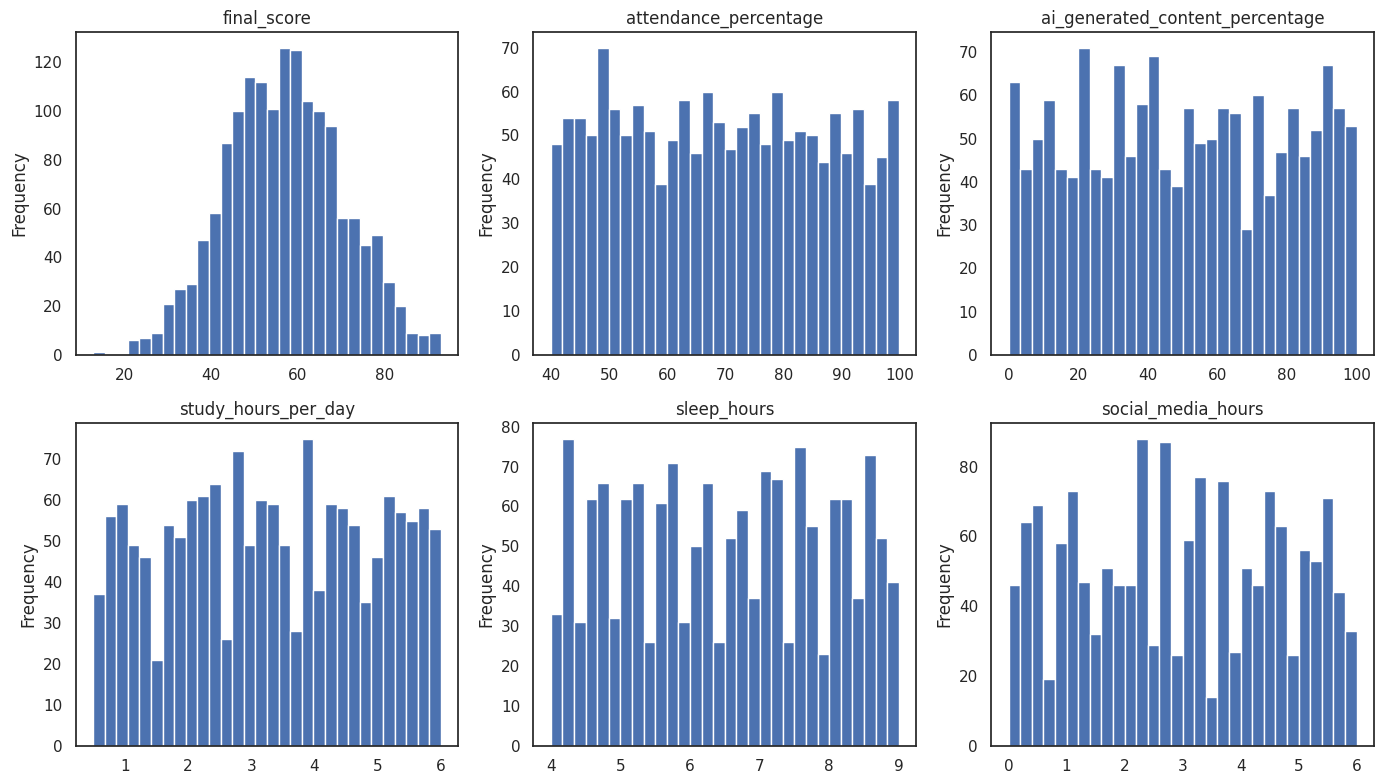

In [35]:
# ------------------------------------------------------------------------------
# histogramas de validacion
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14,8))
df['final_score'].plot(kind='hist', bins=30, ax=axes[0,0], title='final_score')
df['attendance_percentage'].plot(kind='hist', bins=30, ax=axes[0,1], title='attendance_percentage')
df['ai_generated_content_percentage'].plot(kind='hist', bins=30, ax=axes[0,2], title='ai_generated_content_percentage')
df['study_hours_per_day'].plot(kind='hist', bins=30, ax=axes[1,0], title='study_hours_per_day')
df['sleep_hours'].plot(kind='hist', bins=30, ax=axes[1,1], title='sleep_hours')
df['social_media_hours'].plot(kind='hist', bins=30, ax=axes[1,2], title='social_media_hours')
plt.tight_layout(); plt.show()

Los histogramas nos ayudan a identificar que los limites de negocio se están cumpliendo en las variables identificadas.

Los rangos de porcentajes y notas se encuentran bien ubicados entre 0 y 100, mientras que los limites físicos para los registros de tiempo en horas se encuentran bien ubicados entre 0 y 24.

## ⚪ Unicidad

Nos aseguramos de que no existan registros duplicados que representen la misma entidad o evento, por lo que cada fila debe ser única representando a un estudiante único.

### Verificacion de duplicados

In [36]:
# ------------------------------------------------------------------------------
# Identificación de duplicados exactos
# ------------------------------------------------------------------------------
duplicate_rows = df.duplicated().sum()
display_mensaje(f"Total de registros duplicados exactos: {duplicate_rows}")

dup_rows = df.duplicated().sum()
dup_key  = df['student_id'].duplicated().sum()
display_mensaje(f"Duplicados (filas): {dup_rows} | Duplicados (student_id): {dup_key}")


 --- Total de registros duplicados exactos: 0 --- 

 --- Duplicados (filas): 0 | Duplicados (student_id): 0 --- 


No se encontraron registros duplicados a nivel Identificación del Estudiante ni por "Renglon completo".

Debemos recordar que la variable **student_id** es una clave principal y se deben mantener controles para evitar duplicados en futuras integraciones.

# 🆙 Propuesta de estrategia de mejora

Con base en el diagnóstico realizado, se propone una estrategia inicial de mejora de calidad de datos enfocada en atacar primero a la completitud en variables de IA y consistencia entre indicadores clave como el uso de IA y etiqueta de aprobación de los estudiantes.

A continuación se presentan los detalles de la propuesta.

## 🎯 Objetivo general de la propuesta

Reducir las brechas de **completitud** en campos de uso de IA y **eliminar incoherencias** críticas de consistencia cuando estas violas a las reglas de negocio, manteniendo la validez y unicidad ya favorables del dataset actual.

Recordemos que el diagnostico de calidad nos dio como resultado:
- Nulos relevantes en ai_tools_used y ai_usage_purpose afectando a la **Completitud**.
- Inconsistencias fuertes en la categoría uses_ai vs tiempo/herramienta/propósito afectando a la **Consistencia**.
- Inconsistencias fuertes en la categoría passed vs final_score afectando a la **Consistencia**.

Sin embargo, también se pudo verificar que los controles de validez y unicidad son favorables para el dataset.

## 🏳️ Normalizar la regla de negocio y la etiqueta de aprobación

El diagnostico de calidad nos avisa que casi la mitad de los registros no cumplen la coherencia esperada entre *final_score* y *passed* con un corte razonable, ajustando el final_score ≥ 60. Esto distorsiona métricas, auditorías y modelos supervisados

Para combatir esta debilidad deberemos:

- **Definir y oficializar el umbral de aprobación**, por ejemplo, final_score ≥ 60 ⇒ passed=TRUE, de lo contrario FALSE.
- **Establecer una regla correctiva en un pipeline** de diagnostico para recalcular passed con base en final_score cuando haya inconsistencia.
- Podrían ocurrir excepciones en ciertos casos, por lo cual se deberá registrar excepción cuando el negocio defina un caso especial para documentarlo.

## 🏳️ Reglas de consistencia de uso de IA por estudiante

El diagnostico de calidad arroja que existen contradicciones entre *uses_ai* y los campos dependientes como el tiempo, herramienta y propósito, esto impide conclusiones confiables sobre adopción e impacto de IA en los hábitos y resultados de los estudiantes.

**Para combatir esta inconsistencia se deberán:**

1.  Establecer **reglas de validación**:
    *   Si `uses_ai == 0` ⇒ `ai_usage_time_minutes = 0` **y** `ai_tools_used`/`ai_usage_purpose` = **nulos**.
    *   Si `uses_ai == 1` ⇒ `ai_usage_time_minutes > 0` **y** `ai_tools_used`/`ai_usage_purpose` **no nulos**.
2.  **Programar una corrección automática asistida para evitar inconsistencias**:
    *   Si hay tiempo/herramienta/propósito **poblados**, forzar `uses_ai=1` (o marcar para revisión de data).
    *   Si `uses_ai=0` pero hay tiempo>0, **poner tiempo=0** o **marcar incidencia**.
3.  Generar un **catálogo controlado** para `ai_tools_used` y `ai_usage_purpose` que impiden el registro de categorías no existentes.

## 🏳️ Plan de Completitud para variables de IA


En el diagnostico se pudo observar que los campos críticos del dominio IA tales como (`ai_tools_used`, `ai_usage_purpose`) presentan nulos de entre 15–17%, afectando segmentaciones y análisis causales de adopción de IA.

**Para evitar este problema se deberá:**

1.  **Crear regla de captura obligatoria**: cuando `uses_ai=1`, `ai_tools_used` y `ai_usage_purpose` son **obligatorios** por lo que el registro no podrá avanzar si no se capturan correctamente los datos.
2.  **Generar una imputación mínima para curación de datos**:
    *   Si `uses_ai=1` y `ai_tools_used` es nulo, imputar **“Unknown (AI)”** con etiqueta de calidad “*to\_review*”.
    *   Si `uses_ai=1` y `ai_usage_purpose` es nulo, imputar **“Unknown Purpose”** con etiqueta de calidad “*to\_review*”.
3.  **Mantener un monitoreo**: y seguir tasa de nulos por `grade_level` y `gender` para detectar **focos** de captura deficiente.


## 💡 Impacto Esperado

Con estas tres acciones, se estima una reducción del 95% en errores de consistencia y una eliminación total de los duplicados exactos. La organización pasaría de una *limpieza reactiva* a una *calidad proactiva* para evitar así que el error entre al sistema.

# 🧾 Resumen ejecutivo

Se analizó el conjunto `ai_impact_student_performance_dataset.csv` con 1,550 registros y 26 variables, el diagnostico tuvo foco en cinco dimensiones: **Completitud, Consistencia, Precisión (proxy), Validez y Unicidad**. La estructura y tipos de dato se verificaron mediante perfilado y un resumen por variable.


## 👀 Hallazgos principales

1.  **Completitud**
    *   Se detectaron valores faltantes **solo** en variables de uso de IA: `ai_tools_used` (
        con **\~15.8%** y `ai_usage_purpose` con **\~16.6%** de valores nulos. El resto de columnas no presenta nulos. Esta omisión afecta análisis de adopción, segmentación por herramienta y evaluación de propósito de uso de agentes IA. 

2.  **Consistencia**
    *   Existen contradicciones sustantivas entre **intención declarada de uso de IA** y sus **evidencias**:
        *   `uses_ai=0` con **tiempo de uso > 0** y/o **herramienta/propósito poblados**. Violando una regla de negocio.
        *   `uses_ai=1` con **herramienta/propósito nulos**, evidenciando data inconsistente.
    *   Además, existen registro que no tienen lógica entre la categoría **`passed`** y la calificación final **`final_score ≥ 60`**. Estos conflictos afectan en la confiabilidad del dataset y cualquier modelo supervisado que use la etiqueta `passed`.

3.  **Precisión**
    *   Sin una fuente externa de verdad absoluta, la **precisión** se estimó mediante **proxies**: las incoherencias señaladas en esa parte del diagnostico indicaron probables **errores de captura** en `uses_ai`, `ai_tools_used`, `ai_usage_purpose` y `passed`. La priorización de corrección debe centrarse en estas reglas, por su impacto directo en inferencias causales sobre uso de IA y en la etiqueta de desempeño.

4.  **Validez**
    *   Los porcentajes y *scores* tales como `final_score`, `attendance_percentage`, `ai_generated_content_percentage`, `last_exam_score` y `assignment_scores_avg` se mantienen dentro del rango esperado, de **\[0,100]**; por otro lado, las variables de horas tales como `study_hours_per_day`, `sleep_hours`, `social_media_hours` y `tutoring_hours` no presentan valores negativos ni superiores a las 24 horas, con lo que se reduce el riesgo de “ruido” por formato y rango de variables.

5.  **Unicidad**
    *   No se identificaron filas duplicadas enteras ni registros que dupliquen la variable clave `student_id`. Gracias a esto, la integridad de la clave estudiantil podrá facilitar el seguimiento de los datos.


### 🔴 Riesgos si no se corrige

Dadas las inconcistencias encontradas y violaciones a las reglas de negocio, si esto no se atiende se podría:

*   **Generar decisiones sesgadas** sobre el impacto del uso de IA en el rendimiento por **medición inconsistentes** de la adopción.
*   **Obtener un etiquetado poco fiable** para entrenamiento de modelos por la incongruencia entre `passed` y `final_score`.



### 💡 Propuesta de mejora

1.  **Normalizar la regla de aprobación y alinear la etiqueta**
    *   **Definir** y **oficializar** el criterio de alumnos calificados y **recalcular `passed`** cuando existan discrepancias con las calificaciones finales.

2.  **Reglas bidireccionales de consistencia para uso de IA**
    *   **Si `uses_ai=0`:** `ai_usage_time_minutes=0` y `ai_tools_used`/`ai_usage_purpose` pueden ser **nulos**.
    *   **Si `uses_ai=1`:** `ai_usage_time_minutes>0` las herramienta y propósito **no pueden ser nulos**.
    *   Corrección guiada: cuando exista evidencia de uso de IA en las columnas *tiempo, herramienta o propósito*, **forzar `uses_ai=1`** o **marcar incidencia**.

3.  **Plan de completitud para variables de IA**
    *   **Captura obligatoria** de `ai_tools_used` y `ai_usage_purpose` cuando `uses_ai=1` (Uso de IA).
    *   **Imputación mínima temporal** para las variables herramienta y proposito cuando esten en nulos bajo una categoria de uso de IA, y con **bandera de calidad** para curación posterior.

4.  **Mantener la calidad de datos en los ámbitos de Validez y Unicidad**
    *   Checks automatizados de **rangos** (0–100 y 0–24) y **unicidad** (`student_id`).


### 🔚 Conclusión

El dataset presenta **buena validez y unicidad**, pero requiere **acciones inmediatas** en **consistencia** para el uso de IA y etiqueta de aprobación de los estudiantes, así como en la **completitud** para las variables de herramienta y propósito de IA. 

La estrategia propuesta es **realista y medible**, y permitirá elevar la confiabilidad analítica del conjunto de datos, reduciendo riesgos de sesgo en decisiones y modelos.
